In [5]:
from src.utils import get_path, find_closest_power_of_2
from src.QDDPM_torch_angel import QDDPM, WassDistance
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST0',
    }
}
n_data, n_pixels, n_timesteps, n_ancilla_qubits, n_backward_layers = 1000, 64, 40, 4, 9
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'linear1'

/tmp/ipykernel_2020087/599815300.py:2: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  fig, axs = plt.subplots(np.int(np.ceil(n_timesteps/5)), 5, figsize=(size, size+2), sharex=True, sharey=True)


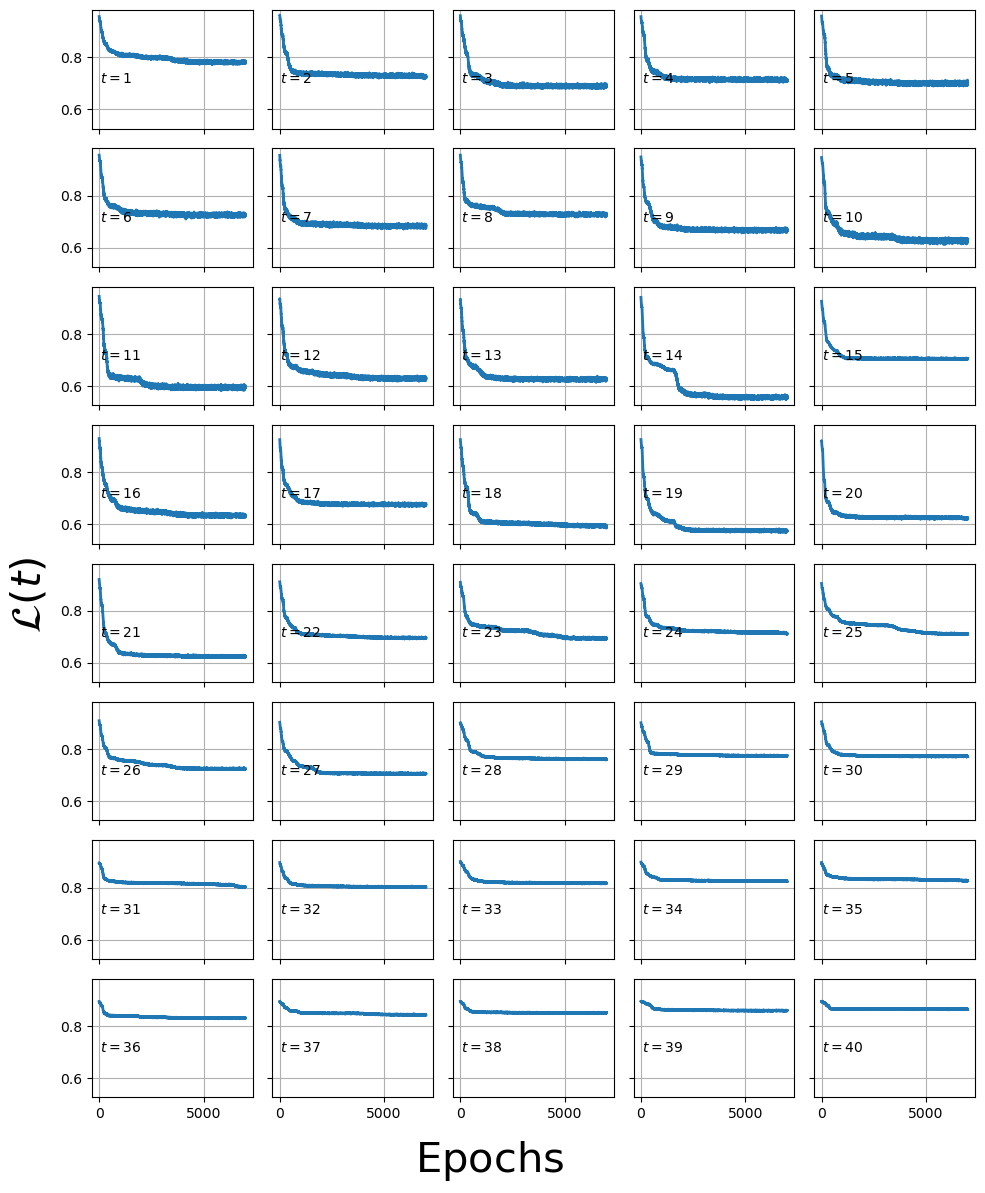

In [2]:
size = 10
fig, axs = plt.subplots(np.int(np.ceil(n_timesteps/5)), 5, figsize=(size, size+2), sharex=True, sharey=True)
for i in range(n_timesteps):
    # if i < 11:
    #     continue
    dir, filename = get_path(config, type='modelfinallosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=i+1)
    loss = np.load(dir / filename)
    axs[i//5, i%5].plot(loss, lw=2)
    # axs[i//5, i%5].tick_params(direction='in', length=6, width=2, top='on', right='on', labelsize=20)
    axs[i//5, i%5].text(x=30, y=0.7, s=r'$t=%d$'%(i+1), fontsize=10)
    # axs[i//5, i%5].set_yscale('log')
    axs[i//5, i%5].grid(True)
fig.supxlabel(r'$\rm Epochs$', fontsize=30)
fig.supylabel(r'$\mathcal{L}(t)$', fontsize=30)
plt.tight_layout()

In [3]:
# Compute Wasserstein distance across timesteps
wassbackwardtrain = np.zeros(n_timesteps)
for i in range(n_timesteps):
    dir, filename = get_path(config, type='modellosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=i+1)
    loss = np.load(dir / filename)

    wassbackwardtrain[i] = loss[-1]

# Backward training (last element of the loss history of each timestep)

Text(0.5, 1.0, 'Lowest Wasserstein distance across timesteps')

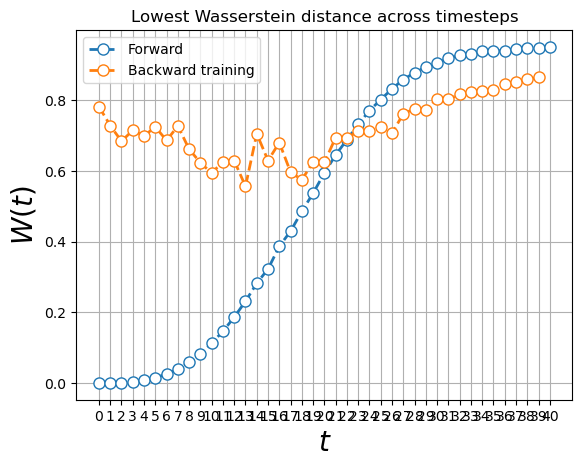

In [6]:
# Plot it

dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers)
wassforward = np.load(dir / filename)

plt.plot(wassforward, 'o--', label='Forward', mfc='white', markersize=8, lw=2)
plt.plot(wassbackwardtrain, 'o--', label='Backward training', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$W(t)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.xticks(range(n_timesteps+1))
plt.grid(True)
plt.legend()
plt.title('Lowest Wasserstein distance across timesteps')

In [18]:
# Compute the images across timesteps.
device = torch.device('cpu')
model = QDDPM(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers, device=device).to(device)

# Load just one corrupted state
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits,n_timesteps=n_timesteps)
states_diffused = np.load(dir / filename)
diffused_state = states_diffused[-1, 0] # Last timestep, first sample


# Load the parameters, sample using the model and compute the images

params_tot = torch.zeros((n_timesteps, 2*(n_qubits+n_ancilla_qubits)*n_backward_layers), device=device)
for tt in range(1, n_timesteps+1):
    dir, filename = get_path(config, type='modelparams', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=tt)
    params_tot[tt-1] = torch.from_numpy(np.load(dir / filename)).to(device)

inputs_last_timestep = torch.from_numpy(states_diffused[-1]).to(device)
outputs = torch.zeros((n_timesteps+1, n_data, 2**(n_qubits)), device=device)
for t in range(1, n_timesteps+1):
    input_tplus1 = model.prepareInput_t(inputs_last_timestep, params_tot, t, n_data)
    outputs[t-1] = model.backwardOutput_t(input_tplus1, params_tot[t-1])

outputs[-1] = inputs_last_timestep

  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 2356.67it/s]


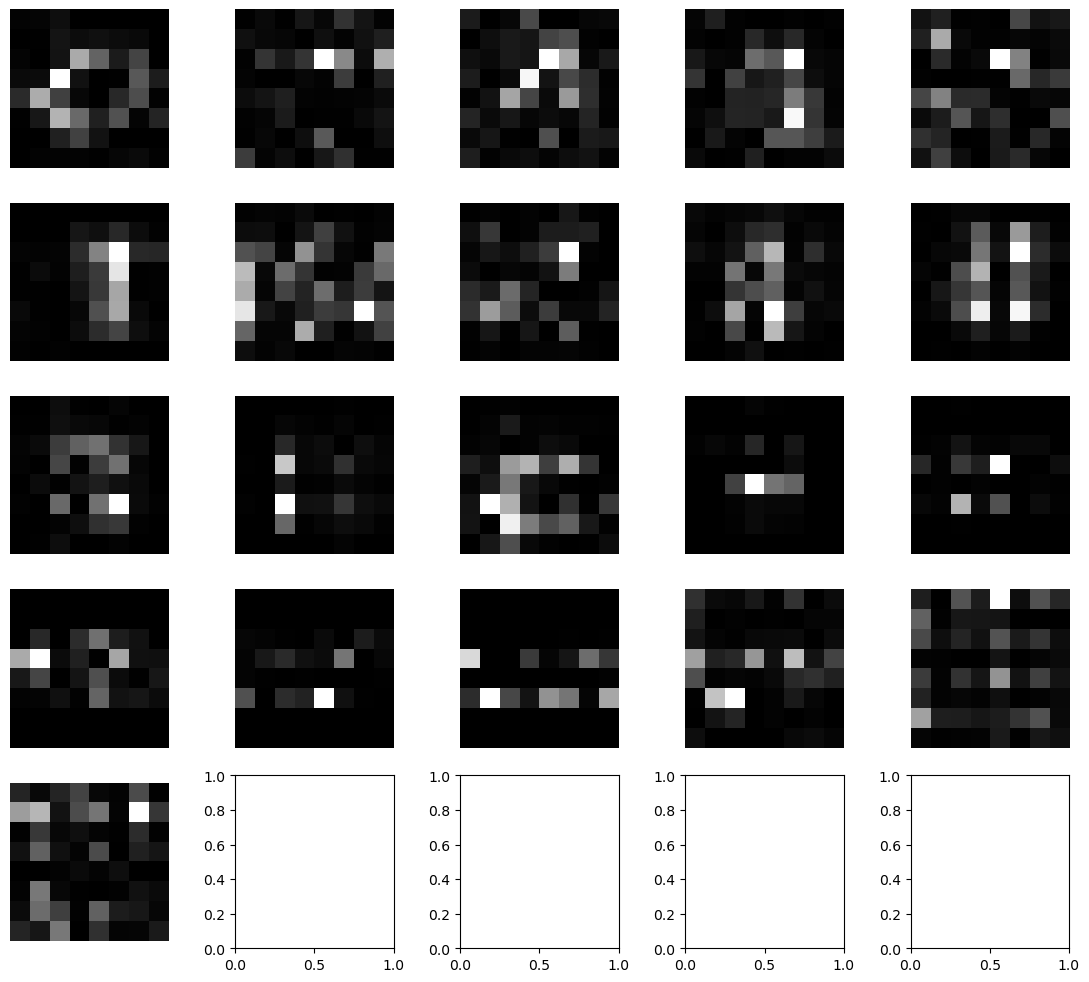

In [22]:
# Visualize the evolution of one image
n = 3 # select a sample

image_dim = int(np.sqrt(n_pixels))
fig, axs = plt.subplots(5,5, figsize=(11,10))
vmin, vmax = 0, 1
images = []
for i in tqdm(range(n_timesteps+1)):
    # Extract the probabilities and convert back to MNIST digits
    state = outputs[i, n]
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_pixels]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1]
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i//5, i%5].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i//5, i%5].axis('off')

plt.tight_layout()